In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


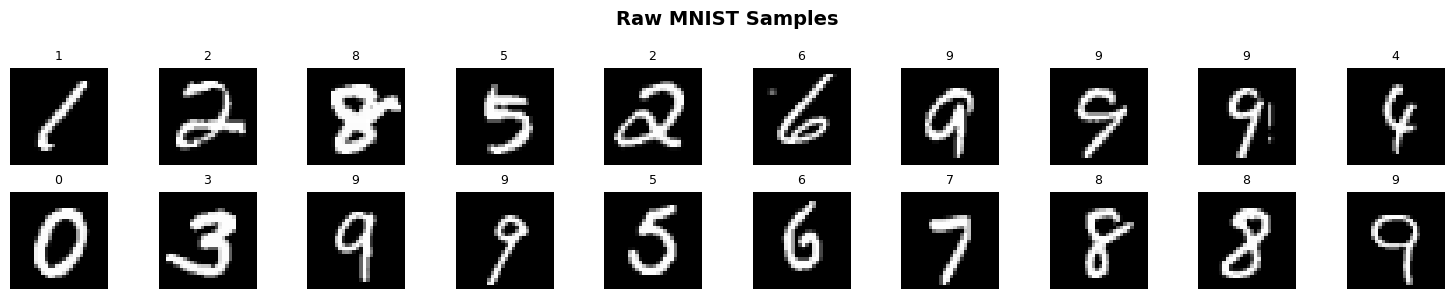

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True,  transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("Raw MNIST Samples", fontsize=14, fontweight='bold')
for i in range(20):
    ax = axes[i // 10][i % 10]
    ax.imshow(sample_imgs[i].squeeze(), cmap='gray')
    ax.set_title(str(sample_labels[i].item()), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.fc1        = nn.Linear(input_dim,  hidden_dim)
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h       = F.relu(self.fc1(x))
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

In [4]:
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=400, output_dim=784):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim,  hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,  output_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        return torch.sigmoid(self.fc2(h))

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, log_var     = self.encoder(x)
        z               = reparameterize(mu, log_var)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, log_var

In [7]:
LATENT_DIM = 2
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model      = VAE(latent_dim=LATENT_DIM).to(device)

dummy = torch.randn(1, 784).to(device)
mu, log_var = model.encoder(dummy)
z           = reparameterize(mu, log_var)
out         = model.decoder(z)

print(f"Input:   {dummy.shape}")
print(f"μ:       {mu.shape}")
print(f"log σ²:  {log_var.shape}")
print(f"z:       {z.shape}")
print(f"Output:  {out.shape}")

Input:   torch.Size([1, 784])
μ:       torch.Size([1, 2])
log σ²:  torch.Size([1, 2])
z:       torch.Size([1, 2])
Output:  torch.Size([1, 784])


In [8]:
BETA = 1

def vae_loss(x_recon, x_orig, mu, log_var):
    recon_loss = F.binary_cross_entropy(x_recon, x_orig, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + BETA * kl_loss, recon_loss, kl_loss

In [9]:
EPOCHS = 15
LR     = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history   = {"total": [], "recon": [], "kl": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_sum, recon_sum, kl_sum = 0, 0, 0

    for images, _ in train_loader:
        images = images.view(-1, 784).to(device)

        x_recon, mu, log_var      = model(images)
        loss, recon_loss, kl_loss = vae_loss(x_recon, images, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon_loss.item()
        kl_sum    += kl_loss.item()

    n = len(train_loader.dataset)
    history["total"].append(total_sum / n)
    history["recon"].append(recon_sum / n)
    history["kl"].append(kl_sum    / n)

    print(f"Epoch [{epoch:>2}/{EPOCHS}]  "
          f"Total: {total_sum/n:8.3f}  "
          f"Recon: {recon_sum/n:8.3f}  "
          f"KL: {kl_sum/n:7.3f}")

Epoch [ 1/15]  Total:  189.638  Recon:  183.994  KL:   5.644
Epoch [ 2/15]  Total:  167.613  Recon:  162.230  KL:   5.384
Epoch [ 3/15]  Total:  163.585  Recon:  158.194  KL:   5.391
Epoch [ 4/15]  Total:  161.379  Recon:  155.943  KL:   5.436
Epoch [ 5/15]  Total:  159.762  Recon:  154.265  KL:   5.498
Epoch [ 6/15]  Total:  158.490  Recon:  152.926  KL:   5.564
Epoch [ 7/15]  Total:  157.363  Recon:  151.754  KL:   5.609
Epoch [ 8/15]  Total:  156.450  Recon:  150.775  KL:   5.675
Epoch [ 9/15]  Total:  155.610  Recon:  149.890  KL:   5.720
Epoch [10/15]  Total:  154.926  Recon:  149.154  KL:   5.772
Epoch [11/15]  Total:  154.251  Recon:  148.457  KL:   5.794
Epoch [12/15]  Total:  153.730  Recon:  147.867  KL:   5.862
Epoch [13/15]  Total:  153.236  Recon:  147.334  KL:   5.902
Epoch [14/15]  Total:  152.731  Recon:  146.819  KL:   5.913
Epoch [15/15]  Total:  152.288  Recon:  146.350  KL:   5.938


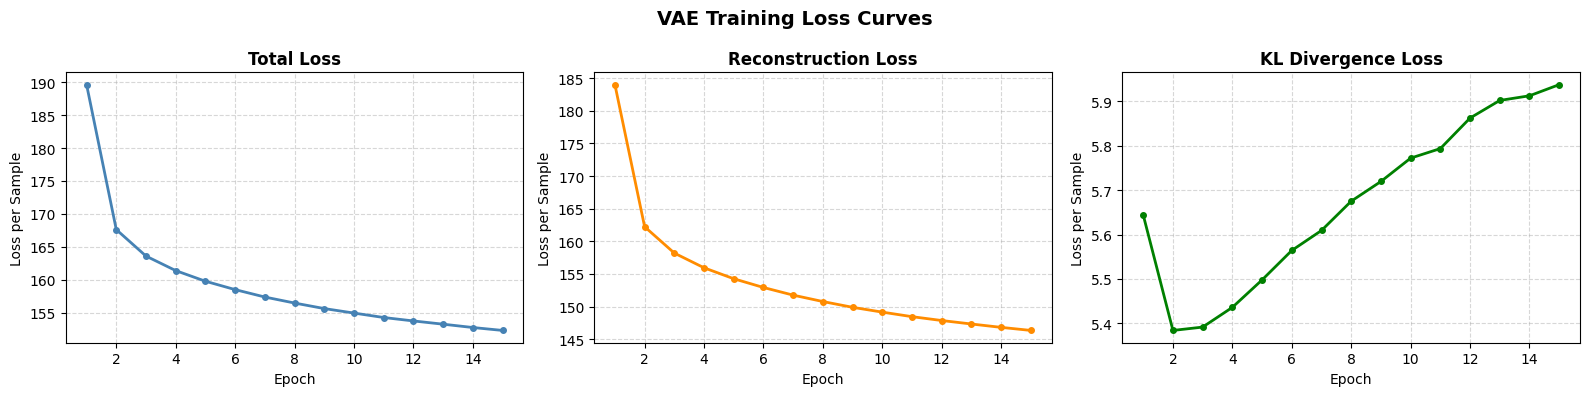

In [10]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("VAE Training Loss Curves", fontsize=14, fontweight='bold')

for ax, title, key, color in zip(
    axes,
    ["Total Loss", "Reconstruction Loss", "KL Divergence Loss"],
    ["total", "recon", "kl"],
    ["steelblue", "darkorange", "green"]
):
    ax.plot(epochs_range, history[key], color=color, linewidth=2, marker='o', markersize=4)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss per Sample")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

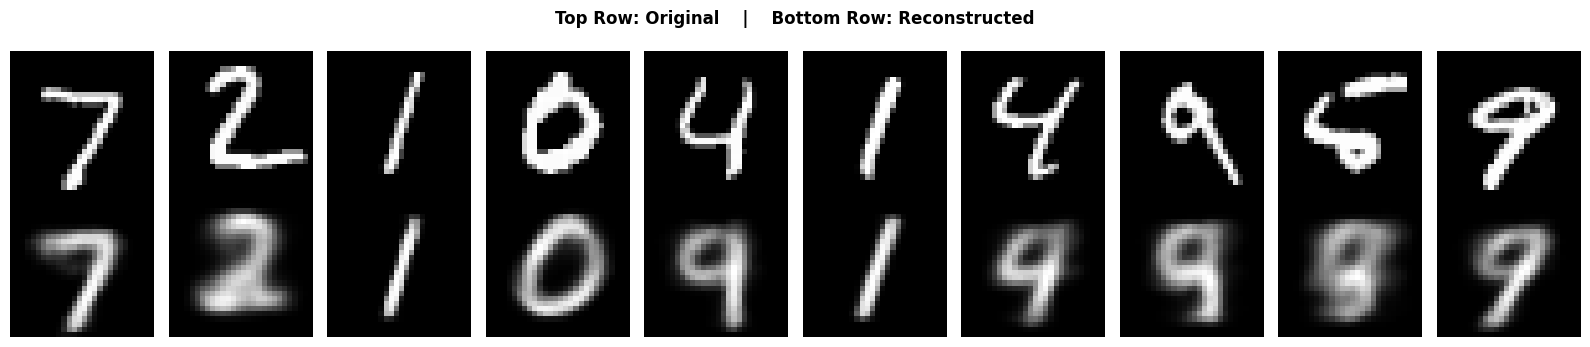

In [11]:
model.eval()
test_imgs, _ = next(iter(test_loader))

with torch.no_grad():
    reconstructed, _, _ = model(test_imgs.view(-1, 784).to(device))

originals     = test_imgs[:10].squeeze().cpu().numpy()
reconstructed = reconstructed[:10].view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle("Top Row: Original    |    Bottom Row: Reconstructed", fontsize=12, fontweight='bold')

for i in range(10):
    axes[0][i].imshow(originals[i],     cmap='gray'); axes[0][i].axis('off')
    axes[1][i].imshow(reconstructed[i], cmap='gray'); axes[1][i].axis('off')

axes[0][0].set_ylabel("Original",      fontsize=10, fontweight='bold')
axes[1][0].set_ylabel("Reconstructed", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

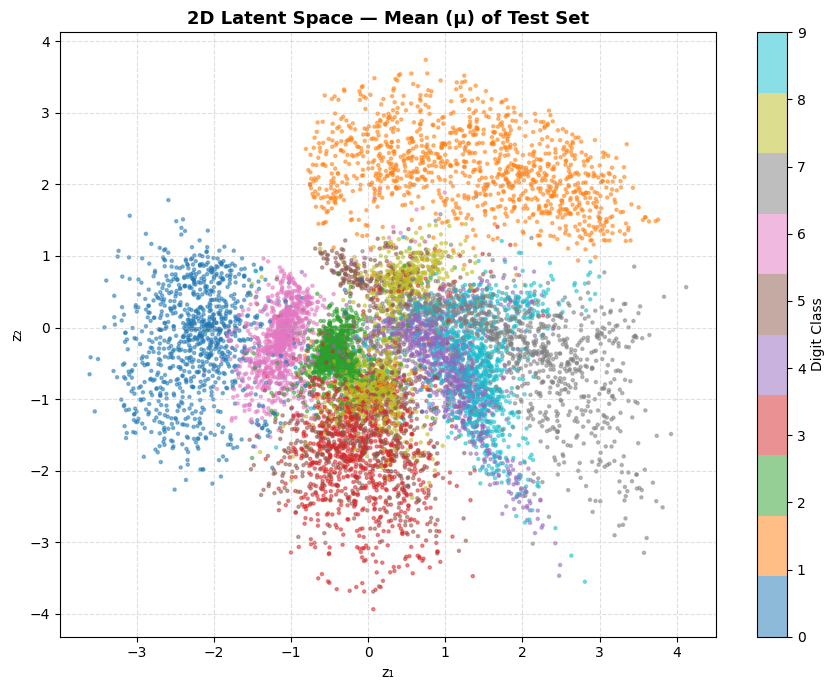

In [12]:
model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        mu, _ = model.encoder(images.view(-1, 784).to(device))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu)
all_labels = np.concatenate(all_labels)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("2D Latent Space — Mean (μ) of Test Set", fontsize=13, fontweight='bold')
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

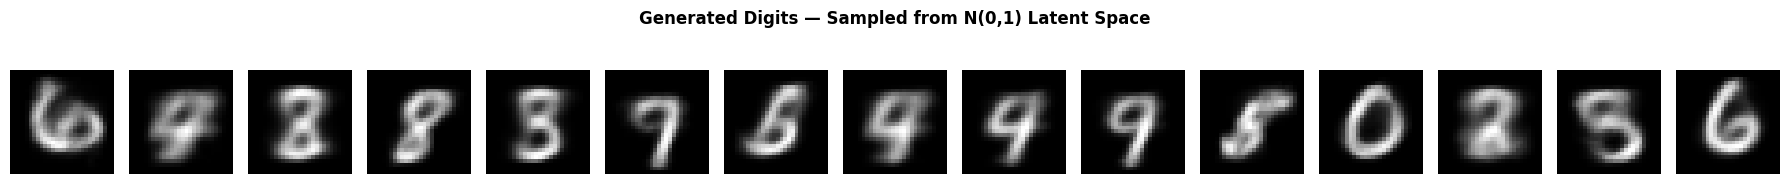

In [13]:
model.eval()
num_samples = 15

with torch.no_grad():
    z         = torch.randn(num_samples, LATENT_DIM).to(device)
    generated = model.decoder(z).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(1, num_samples, figsize=(18, 2))
fig.suptitle("Generated Digits — Sampled from N(0,1) Latent Space", fontsize=12, fontweight='bold')

for i, ax in enumerate(axes):
    ax.imshow(generated[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

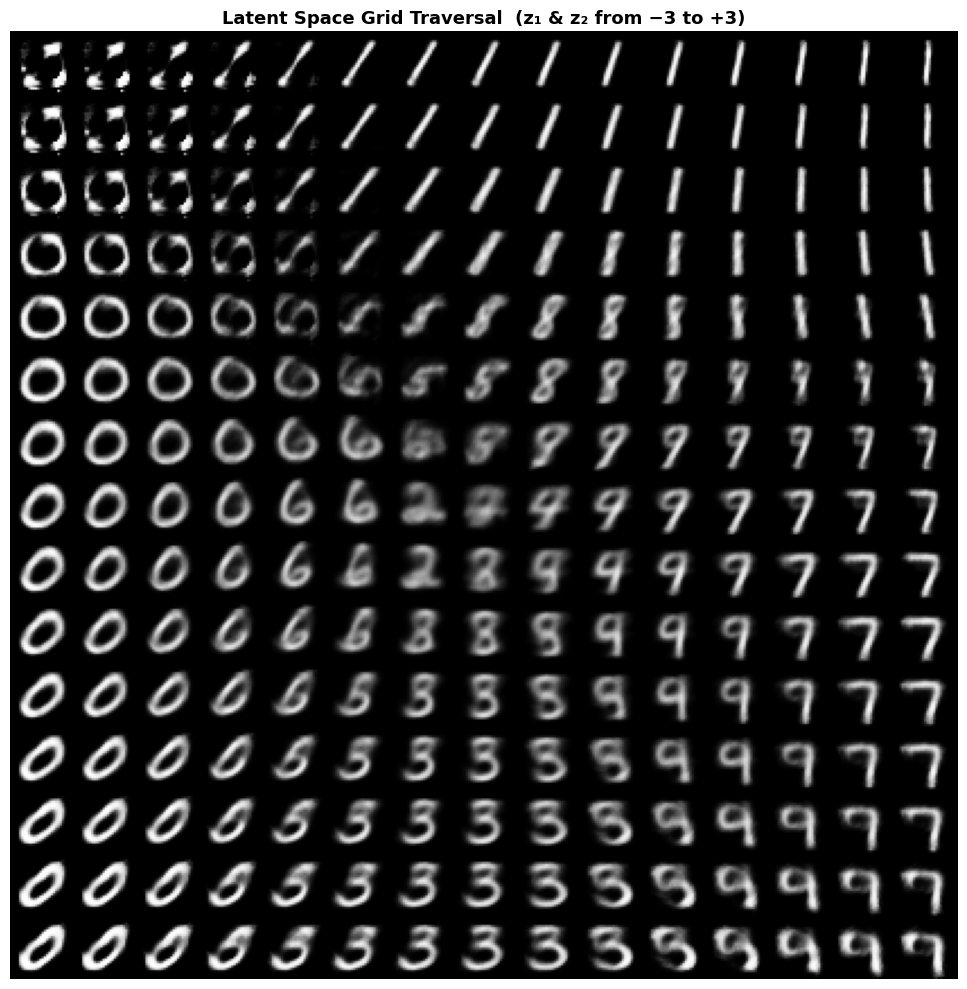

In [14]:
model.eval()
grid_size = 15
z_range   = np.linspace(-3, 3, grid_size)

z1_grid, z2_grid = np.meshgrid(z_range, z_range[::-1])
z_pairs  = np.stack([z1_grid.ravel(), z2_grid.ravel()], axis=1)
z_tensor = torch.tensor(z_pairs, dtype=torch.float).to(device)

with torch.no_grad():
    imgs = model.decoder(z_tensor).view(-1, 28, 28).cpu().numpy()

canvas = imgs.reshape(grid_size, grid_size, 28, 28) \
             .transpose(0, 2, 1, 3) \
             .reshape(grid_size * 28, grid_size * 28)

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap='gray')
plt.title("Latent Space Grid Traversal  (z₁ & z₂ from −3 to +3)", fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**Conclusion**

**1. Encoder & Latent Space Parameterization**

The encoder does not map input directly to a fixed point in latent space. Instead, it learns a probability distribution, outputting a mean vector μ and a log-variance vector log(σ²) for each input.

This forces the model to represent each input as a region in latent space rather than a single point, enabling smooth interpolation and generalization.

Using log(σ²) instead of σ² directly ensures numerical stability and allows the network to output unconstrained real values.

**2. Reparameterization Trick**

Sampling z ~ N(μ, σ²) directly breaks the backpropagation chain because the sampling operation is non-differentiable.

The trick rewrites it as z = μ + ε·σ where ε ~ N(0, I), separating the stochastic part (ε) from the learnable parameters (μ, σ). This makes the gradient flow through μ and σ during training, making the whole network end-to-end differentiable.

The reparameterization is kept as a standalone function to make this step explicit and easy to identify — it is the single most important trick that makes VAE training possible.

Observation: Without this trick, the VAE cannot be trained with standard gradient descent.

**3. Decoder & Reconstruction**

The decoder learns the inverse mapping, taking a latent vector z and reconstructing the original input.

A sigmoid activation in the final layer ensures pixel values are bounded in [0, 1], matching the normalized MNIST input range.

Observation: Early in training, reconstructions appear blurry and distorted. As training progresses, the decoder learns sharper and more accurate digit representations. Blurriness is an inherent property of VAEs because the model averages over the distribution of possible outputs — this is a known trade-off compared to GANs.

**4. Reconstruction Loss (Binary Cross-Entropy)**

BCE was chosen over MSE because MNIST pixels are normalized to [0, 1], treating each pixel as a Bernoulli random variable. BCE is the standard choice for this range and penalizes confident wrong predictions more heavily than MSE would.

Defined as:

Recon Loss = − Σ [ x·log(x̂) + (1−x)·log(1−x̂) ]

Observation: Reconstruction loss dominates early training and decreases significantly as the decoder improves. Lower reconstruction loss = sharper, more accurate digit reconstructions.

**5. KL Divergence Loss**

Acts as a regularizer on the latent space. It measures how much the learned distribution q(z|x) deviates from the standard normal prior p(z) = N(0, I).

Defined as:

KL Loss = −0.5 · Σ [ 1 + log(σ²) − μ² − σ² ]

Observation: KL loss starts low and gradually increases before stabilizing — this is the model learning to use the latent space meaningfully while staying close to the prior. If KL loss collapses to ~0, it means the encoder is ignoring the input (posterior collapse), a common failure mode.

**6. Total VAE Loss (ELBO)**

The VAE optimizes the Evidence Lower Bound (ELBO):

Total Loss = Reconstruction Loss + β · KL Divergence Loss

β is set to 1 here (standard VAE). Increasing β beyond 1 produces a β-VAE, which enforces stronger disentanglement in the latent space at the cost of reconstruction quality — a useful knob to demonstrate the tradeoff between reconstruction fidelity and latent structure.

There is a natural tension: reconstruction loss pushes the encoder to encode as much information as possible, while KL loss pushes the latent distribution toward N(0,1), compressing it.

Observation: Total loss steadily decreases across all epochs, showing the model is learning effectively. Loss values are reported per sample (divided by dataset size) to allow fair comparison with literature.

**7. Latent Space Structure**

A well-trained VAE produces a structured, continuous latent space where similar digits cluster together and boundaries between clusters are smooth, not sharp.

LATENT_DIM = 2 was chosen intentionally — not for model performance, but to allow direct 2D visualization of the latent space without any dimensionality reduction. Each point in the scatter plot is the μ value of a test image, directly projected into 2D.

Observation: Digits of the same class (0–9) form distinct but slightly overlapping regions. The overlap allows smooth interpolation between classes.

**8. Generative Capability**

Since the latent space is regularized to follow N(0, I), we can sample any random z from this distribution and decode it into a valid image.

Observation: Generated samples resemble recognizable digits even though no specific digit was targeted — the decoder has generalized the data distribution. This is what separates a VAE from a plain autoencoder: a regular AE has no structured latent space, so random sampling produces meaningless noise.

**9. Latent Space Grid Traversal**

By decoding points on a uniform 2D grid across the latent space, we observe smooth morphing between digit classes. All 225 grid points (15×15) are decoded in a single vectorized forward pass.

Observation: Moving along the z₁ or z₂ axis causes gradual visual transitions — e.g., a 1 slowly morphing into a 7, or a 3 into an 8. This confirms the VAE has learned a disentangled, continuous manifold of the digit data.